In [2]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [1]:
import visualization.visualization as vis

In [3]:
from nemi import NEMI, SingleNemi

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import numpy as np

In [5]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [6]:
# cutouts_dataloader = cutouts_dataset.get_cutout_loader(source=source, subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

cutouts_dataloader = cutouts_dataset.get_cutout_loader(data_channels=data_channels, source=source, subset=False, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=4, batch_size=64)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44307 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:42511' processes=4 threads=16, memory=64.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/44307/status
dropped 0 cutouts with sea ice
dropped 0 cutouts with NaN
kept 3250 / 3250 cutouts
Channels : ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'gradb2', 'oceTAUX', 'oceTAUY', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'coriolis_f', 'oceQnet', 'ekman_pumping', 'wind_stress_curl', 'XC', 'YC']


In [7]:
len(cutouts_dataloader) * 64 

3264

In [8]:
patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)

51
(208000, 1408)


In [36]:
# Run NEMI on the patches (GPU: cuML UMAP + clustering)
# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 3, "n_neighbors": 150, "min_dist": 0.0},
#     "clustering_dict": {"method": "hdbscan", "min_cluster_size": 1000, "min_samples": 500},
# })

nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict":  {"n_components": 2, "n_neighbors": 150, "min_dist": 0.0},
    "clustering_dict": {"method": "agglomerative", "n_clusters": 40, "linkage": "single", "n_neighbors": 3},
})


# single member to start; bump n (with assess_overlap=True) for the ensemble
nemi.run(patches, n=5, output="nemi_out.npz", assess_overlap=True)

labels    = nemi.clusters      # (N,) cluster label per patch
embedding = nemi.embedding     # (N, 3) UMAP embedding
print("labels", labels.shape, "| embedding", embedding.shape)

d = np.load("nemi_out.npz")
print(d.files) 

member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
embedding       = d["embedding"]        # (N, d) consensus/base embedding

print(embeddings.shape)
print(member_clusters.shape)
print(clusters.shape)
print(embedding.shape)

  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-17 19:44:10.621] [CUML] [info] Building knn graph using nn descent
[2026-07-17 19:44:10.623] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-17 19:44:10.623] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-17 19:44:16.946] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'agglomerative', 'n_clusters': 40, 'linkage': 'single', 'n_neighbors': 3}


 20%|██        | 1/5 [00:08<00:33,  8.36s/it]

Clusters found: 40
Sorting clusters
Fitting the embedding
[2026-07-17 19:44:18.948] [CUML] [info] Building knn graph using nn descent
[2026-07-17 19:44:18.949] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-17 19:44:18.949] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-17 19:44:25.121] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'agglomerative', 'n_clusters': 40, 'linkage': 'single', 'n_neighbors': 3}


 40%|████      | 2/5 [00:16<00:24,  8.26s/it]

...

 80%|████████  | 4/5 [00:33<00:08,  8.52s/it]

Clusters found: 40
Sorting clusters
Fitting the embedding
[2026-07-17 19:44:44.099] [CUML] [info] Building knn graph using nn descent
[2026-07-17 19:44:44.101] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-17 19:44:44.101] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-17 19:44:50.583] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'agglomerative', 'n_clusters': 40, 'linkage': 'single', 'n_neighbors': 3}


100%|██████████| 5/5 [00:41<00:00,  8.39s/it]

Clusters found: 40
Sorting clusters


40 40
labels (208000,) | embedding (208000, 2)
['embeddings', 'member_clusters', 'clusters', 'embedding']
(5, 208000, 2)
(5, 208000)
(208000,)
(208000, 2)


/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


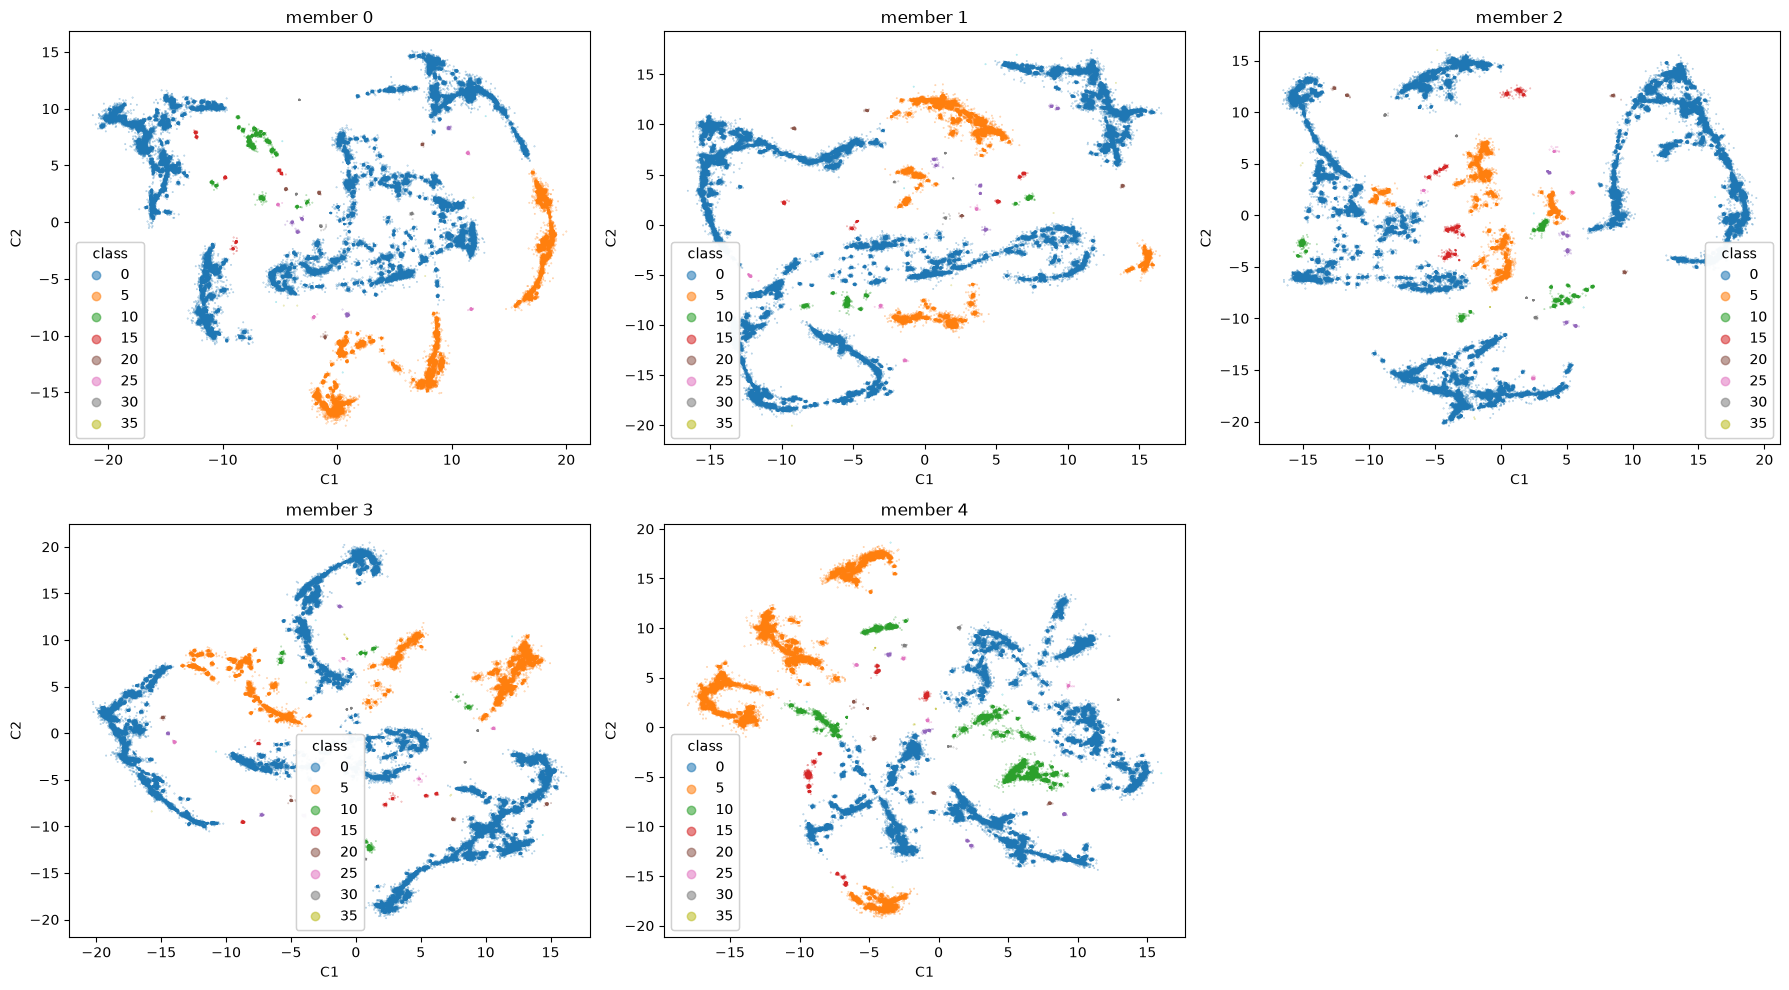

In [37]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=2,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))])

IndexError: index 2 is out of bounds for axis 1 with size 2

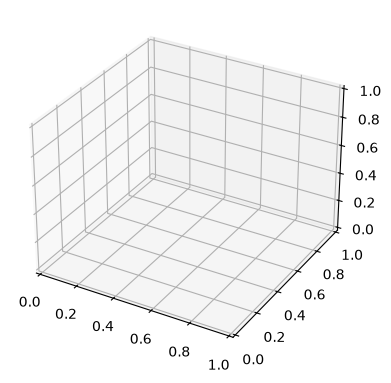

In [38]:
# color every member's embedding by the shared consensus
vis.vis_dim_redux_list(d["embeddings"], labels=d["clusters"], dims=3)

In [21]:
import matplotlib.pyplot as plt
def vis_dim_redux(X_d, labels=None, class_subset=None, label_title="class", dims=2, alpha=0.5):  

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)

        if labels is not None :
    
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                c=labels,
                cmap="tab10",
                alpha=alpha,
                s=.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                alpha=0.1,
                s=.1
            )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                c=labels,
                s=.1,
                cmap="tab10",
                alpha=0.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                alpha=0.1,
                s=.1
            )
            
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()

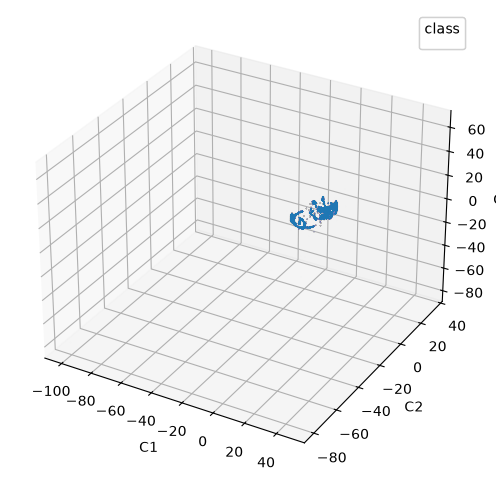

In [22]:
vis_dim_redux(embeddings[2], dims=3, alpha=1)

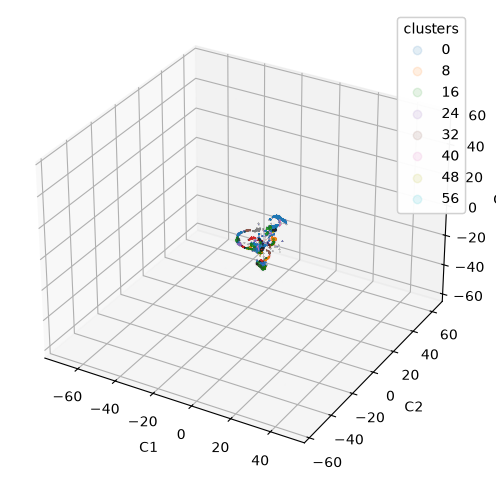

In [26]:
vis_dim_redux(embeddings[0], labels=clusters, class_subset=None, label_title="clusters", dims=3, alpha=1)